# Import Library

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM,Dropout
from tensorflow.keras.callbacks import ModelCheckpoint,EarlyStopping

import warnings
warnings.filterwarnings("ignore")

import os
os.environ["TF_CPP_MIN_LOG_LEVEL"]="3"
tf.compat.v1.logging.set_verbosity(tf.compat.v1.logging.ERROR)

In [ ]:
data=pd.read_csv('/content/metadata-gga-txt.csv')

In [ ]:
data.head()

,Time,DO,Sample_name
0,1.0,282.720001,N4-10-5-01042024-Q=49.81mL_phút-3.txt
1,2.0,282.720001,N4-10-5-01042024-Q=49.81mL_phút-3.txt
2,3.0,282.779999,N4-10-5-01042024-Q=49.81mL_phút-3.txt
3,4.0,282.739990,N4-10-5-01042024-Q=49.81mL_phút-3.txt
4,5.0,282.739990,N4-10-5-01042024-Q=49.81mL_phút-3.txt


# Run with multiple Samples

## Standard LSTM

### Train

In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from keras.optimizers import AdamW
from tensorflow.keras.layers import LSTM, Dropout, Dense
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, Callback
from tensorflow.keras.regularizers import l2
from sklearn.metrics import mean_squared_error
import numpy as np
import tensorflow as tf

# Đặt seed để đảm bảo tính ngẫu nhiên
seed = 42
np.random.seed(seed)
tf.random.set_seed(seed)

# Load data
data = pd.read_csv('/content/metadata-gga-txt.csv')

# List all sample names
sample_names = data['Sample_name'].unique()

# Initialize empty lists to store evaluation results
all_val_losses = []
all_test_losses = []
all_train_rmse = []
all_test_rmse = []
lookback = 7
# Define model with reduced number of neurons
model = Sequential([
    LSTM(128, activation='relu', return_sequences=True, input_shape=(1, lookback)),
    LSTM(64, activation='relu', kernel_regularizer=l2(0.01)),
    Dropout(0.3),
    Dense(1, kernel_regularizer=l2(0.01))
])

# Compile model with different learning rate
model.compile(optimizer=AdamW(learning_rate=0.001), loss='huber')

# Theo dõi loss
sample_loss_history = {}

class LossHistory(Callback):
    def __init__(self, sample_name):
        super().__init__()
        self.sample_name = sample_name
        self.loss_history = []

    def on_epoch_end(self, epoch, logs=None):
        self.loss_history.append(logs.get("loss"))

callbacks = [
    EarlyStopping(monitor="val_loss", patience=10, verbose=1, mode="min"),
    ModelCheckpoint(filepath="best_model_h5.keras", monitor="val_loss", mode="min", save_best_only=True, save_weights_only=False, verbose=0)
]
count = 0
print("len(sample_name)", len(sample_name))

# Feed data into train
for sample_name in sample_names:
    print(f"Processing {sample_name}...")
    print(count)
    # Filter data for the current sample_name
    one_sample_data = data[data['Sample_name'] == sample_name].copy()
    one_sample_data.reset_index(drop=True, inplace=True)
    one_sample_data.drop(['Sample_name'], axis=1, inplace=True)
    one_sample_data.drop("Time", axis=1, inplace=True)
    one_sample_data = one_sample_data.values
    one_sample_data = one_sample_data.astype("float32")

    # Split data into train and test sets
    def split_data(dataframe, train_size, val_size):
        train_end = int(len(dataframe) * train_size)
        val_end = int(len(dataframe) * (train_size + val_size))
        train = dataframe[:train_end]
        val = dataframe[train_end:val_end]
        test = dataframe[val_end:]
        return train, val, test

    train, val, test = split_data(one_sample_data, 0.60, 0.20)

    # Scale data
    scaler_train = MinMaxScaler(feature_range=(0, 1))
    train = scaler_train.fit_transform(train)
    scaler_val = MinMaxScaler(feature_range=(0, 1))
    val = scaler_val.fit_transform(val)
    scaler_test = MinMaxScaler(feature_range=(0, 1))
    test = scaler_test.fit_transform(test)

    # Create features
    def create_features(data, lookback):
        X, Y = [], []
        for i in range(lookback, len(data)):
            X.append(data[i - lookback:i, 0])
            Y.append(data[i, 0])
        return np.array(X), np.array(Y)

    X_train, y_train = create_features(train, lookback)
    X_val, y_val = create_features(val, lookback)
    X_test, y_test = create_features(test, lookback)

    X_train = np.reshape(X_train, (X_train.shape[0], 1, X_train.shape[1]))
    X_val = np.reshape(X_val, (X_val.shape[0], 1, X_val.shape[1]))
    X_test = np.reshape(X_test, (X_test.shape[0], 1, X_test.shape[1]))

    y_train = y_train.reshape(-1, 1)
    y_val = y_val.reshape(-1, 1)
    y_test = y_test.reshape(-1, 1)

    # Tạo LossHistory callback cho mỗi sample_name
    loss_history_callback = LossHistory(sample_name)
    callbacks_with_history = callbacks + [loss_history_callback]

    # Train model with different batch size
    model.fit(x=X_train,
              y=y_train,
              epochs=100,
              batch_size=32,
              validation_data=(X_val, y_val),
              callbacks=callbacks,
              shuffle=False,
              verbose=0)


    # Lưu loss history
    sample_loss_history[sample_name] = loss_history_callback.loss_history

    # Evaluate model
    val_loss = model.evaluate(X_val, y_val, batch_size=32, verbose=0)
    # print(f"\nValidation loss: {100.0 * val_loss:.1f}%")

    test_loss = model.evaluate(X_test, y_test, batch_size=32, verbose=0)
    # print(f"\nTest loss: {100.0 * test_loss:.1f}%")

    train_predict = model.predict(X_train, verbose=0)
    val_predict = model.predict(X_val, verbose=0)
    test_predict = model.predict(X_test, verbose=0)

    train_predict = scaler_train.inverse_transform(train_predict)
    val_predict = scaler_val.inverse_transform(val_predict)
    test_predict = scaler_test.inverse_transform(test_predict)

    y_train = scaler_train.inverse_transform(y_train)
    y_val = scaler_val.inverse_transform(y_val)
    y_test = scaler_train.inverse_transform(y_test)

    train_rmse = np.sqrt(mean_squared_error(y_train, train_predict))
    val_rmse = np.sqrt(mean_squared_error(y_val, val_predict))
    test_rmse = np.sqrt(mean_squared_error(y_test, test_predict))

    # print(f"Train RMSE: {train_rmse:.4f}")
    # print(f"Validation RMSE: {val_rmse:.4f}")
    # print(f"Test RMSE: {test_rmse:.4f}")

    # Append results to lists
    all_val_losses.append(val_loss)
    all_test_losses.append(test_loss)
    all_train_rmse.append(train_rmse)
    all_test_rmse.append(test_rmse)
    count +=1
# Save the model after training
model.save("final_model.h5")

# Print overall evaluation results
print("\nOverall evaluation results:")
print(f"Average val loss: {np.mean(all_val_losses) * 100:.1f}%")
print(f"Average test loss: {np.mean(all_test_losses) * 100:.1f}%")
print(f"Average train RMSE: {np.mean(all_train_rmse):.4f}")
print(f"Average test RMSE: {np.mean(all_test_rmse):.4f}")

len(sample_name) 38
Processing N4-10-5-01042024-Q=49.81mL_phút-3.txt...
0
Processing N4-10-5-27032024-Q=50.45mL_phút-1.txt...
1
Epoch 10: early stopping
Processing N4-10-5-29032024-Q=50.81mL_phút-2.txt...
2
Epoch 11: early stopping
Processing N4-15-10-01042024-Q=49.88mL-phút-2.txt...
3
Epoch 10: early stopping
Processing N4-15-10-27032024-Q=49.66mL_phút-1.txt...
4
Epoch 10: early stopping
Processing N4-5-0-01042024-Q=49.99mL_phút-2.txt...
5
Epoch 12: early stopping
Processing N4-5-0-29032024-Q=50.19mL_phút-1.txt...
6
Epoch 10: early stopping
Processing U1-10-5-02042024-Q=49.74mL_phút-4.txt...
7
Epoch 10: early stopping
Processing U1-10-5-03042024-Q=50.41mL_phút-5.txt...
8
Epoch 10: early stopping
Processing U1-12.5-7.5-04042024-Q=49.9mL_phút-1.txt...
9
Epoch 10: early stopping
Processing U1-12.5-7.5-08042024-Q=50mL_phút-2.txt...
10
Epoch 13: early stopping
Processing U1-15-10-02042024-Q=49.81mL-phút-3.txt...
11
Epoch 10: early stopping
Processing U1-15-10-03042024-Q=50.76mL-phút-4.txt.


Overall evaluation results:
Average val loss: 0.3%
Average test loss: 0.3%
Average train RMSE: 0.8175
Average test RMSE: 2.6103


### Test


Validation loss: 0.3%

Test loss: 0.2%
Train RMSE: 6.8144
Validation RMSE: 1.8869
Test RMSE: 26.4586


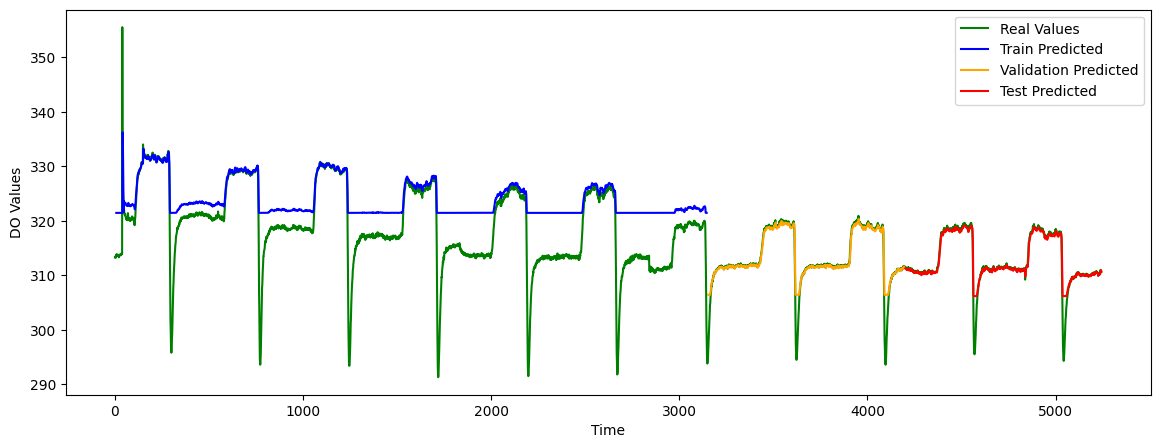

In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import load_model
from sklearn.metrics import mean_squared_error
import numpy as np
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.optimizers import AdamW
from keras.layers import LSTM, Dropout, Dense
from keras.regularizers import l2

# # Load the trained model
model = load_model('/content/final_model.h5')

lookback = 7

# Recreate the model architecture
model = Sequential([
    LSTM(128, activation='relu', return_sequences=True, input_shape=(1, lookback)),
    LSTM(64, activation='relu', kernel_regularizer=l2(0.01)),
    Dropout(0.3),
    Dense(1, kernel_regularizer=l2(0.01))
])

# Load the model weights
# model.load_weights('/content/final_new_model.weights.h5')
model.load_weights('/content/final_model.h5')

model.compile(optimizer=AdamW(learning_rate=0.001), loss='huber') # optimizer = adam hoặc adamW

# Now you can use the model to make predictions
# For example:
# predictions = model.predict(your_input_data)


# Load data
data = pd.read_csv('/content/metadata-gga-txt.csv')
sample_name = 'U100-H3-VS2-7.5-2.5-03072024-Q=50.66mL-phút-5.txt'

# Filter data for the specified sample_name
one_sample_data = data[data['Sample_name'] == sample_name].copy()
one_sample_data.reset_index(drop=True, inplace=True)
one_sample_data.drop(['Sample_name'], axis=1, inplace=True)
one_sample_data.drop("Time", axis=1, inplace=True)
one_sample_data = one_sample_data.values
one_sample_data = one_sample_data.astype("float32")

# Split data into train and test sets
def split_data(dataframe, train_size, val_size):
    train_end = int(len(dataframe) * train_size)
    val_end = int(len(dataframe) * (train_size + val_size))
    train = dataframe[:train_end]
    val = dataframe[train_end:val_end]
    test = dataframe[val_end:]
    return train, val, test

train, val, test = split_data(one_sample_data, 0.60, 0.20)

# Scale data
scaler_train = MinMaxScaler(feature_range=(0, 1))
train = scaler_train.fit_transform(train)
scaler_val = MinMaxScaler(feature_range=(0, 1))
val = scaler_val.fit_transform(val)
scaler_test = MinMaxScaler(feature_range=(0, 1))
test = scaler_test.fit_transform(test)

# Create features
def create_features(data, lookback):
    X, Y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i - lookback:i, 0])
        Y.append(data[i, 0])
    return np.array(X), np.array(Y)

X_train, y_train = create_features(train, lookback)
X_val, y_val = create_features(val, lookback)
X_test, y_test = create_features(test, lookback)

X_train = np.reshape(X_train, (X_train.shape[0], 1, X_train.shape[1]))
X_val = np.reshape(X_val, (X_val.shape[0], 1, X_val.shape[1]))
X_test = np.reshape(X_test, (X_test.shape[0], 1, X_test.shape[1]))

y_train = y_train.reshape(-1, 1)
y_val = y_val.reshape(-1, 1)
y_test = y_test.reshape(-1, 1)

# Evaluate model
val_loss = model.evaluate(X_val, y_val, batch_size=32, verbose=0)
print(f"\nValidation loss: {100.0 * val_loss:.1f}%")

test_loss = model.evaluate(X_test, y_test, batch_size=32, verbose=0)
print(f"\nTest loss: {100.0 * test_loss:.1f}%")

train_predict = model.predict(X_train, verbose=0)
val_predict = model.predict(X_val, verbose=0)
test_predict = model.predict(X_test, verbose=0)

train_predict = scaler_train.inverse_transform(train_predict)
val_predict = scaler_val.inverse_transform(val_predict)
test_predict = scaler_test.inverse_transform(test_predict)

y_train = scaler_train.inverse_transform(y_train)
y_val = scaler_val.inverse_transform(y_val)
y_test = scaler_train.inverse_transform(y_test)

train_rmse = np.sqrt(mean_squared_error(y_train, train_predict))
val_rmse = np.sqrt(mean_squared_error(y_val, val_predict))
test_rmse = np.sqrt(mean_squared_error(y_test, test_predict))

print(f"Train RMSE: {train_rmse:.4f}")
print(f"Validation RMSE: {val_rmse:.4f}")
print(f"Test RMSE: {test_rmse:.4f}")

# Prepare data for visualization
result_data = data[data['Sample_name'] == sample_name].copy()
result_data.reset_index(drop=True, inplace=True) # Reset index for result_data
train_prediction_data = result_data[lookback:len(train)]
val_prediction_data = result_data[len(train)+lookback:len(train)+len(val)]
test_prediction_data = result_data[len(train)+len(val)+lookback:]

train_prediction_data["Predicted"] = train_predict
val_prediction_data["Predicted"] = val_predict
test_prediction_data["Predicted"] = test_predict

# Plotting
plt.figure(figsize=(14, 5))
plt.plot(result_data.index, result_data["DO"], color = "green", label="Real Values")
plt.plot(train_prediction_data.index, train_prediction_data["Predicted"], color="blue", label="Train Predicted")
plt.plot(val_prediction_data.index, val_prediction_data["Predicted"], color="orange", label="Validation Predicted")
plt.plot(test_prediction_data.index, test_prediction_data["Predicted"], color="red", label="Test Predicted")
plt.xlabel("Time")
plt.ylabel("DO Values")
plt.legend()
plt.show()


In [ ]:
# Thay thế các giá trị dự đoán vào các giá trị gốc có cùng thời gian, cùng index
result_data.loc[test_prediction_data.index, "DO"] = test_prediction_data["Predicted"]

print("Updated dataset with predictions:")
result_data.to_csv("result_data.csv",index=False)
display(result_data)

Updated dataset with predictions:


,Time,DO,Sample_name
0,1.0,313.300013,U100-H3-VS2-7.5-2.5-03072024-Q=50.66mL-phút-5.txt
1,2.0,313.300013,U100-H3-VS2-7.5-2.5-03072024-Q=50.66mL-phút-5.txt
2,3.0,313.300013,U100-H3-VS2-7.5-2.5-03072024-Q=50.66mL-phút-5.txt
3,4.0,313.199997,U100-H3-VS2-7.5-2.5-03072024-Q=50.66mL-phút-5.txt
4,5.0,313.600004,U100-H3-VS2-7.5-2.5-03072024-Q=50.66mL-phút-5.txt
...,...,...,...
5239,5240.0,310.711914,U100-H3-VS2-7.5-2.5-03072024-Q=50.66mL-phút-5.txt
5240,5241.0,310.808868,U100-H3-VS2-7.5-2.5-03072024-Q=50.66mL-phút-5.txt
5241,5242.0,310.930756,U100-H3-VS2-7.5-2.5-03072024-Q=50.66mL-phút-5.txt
5242,5243.0,310.833923,U100-H3-VS2-7.5-2.5-03072024-Q=50.66mL-phút-5.txt


### Append to Predict Peaks model

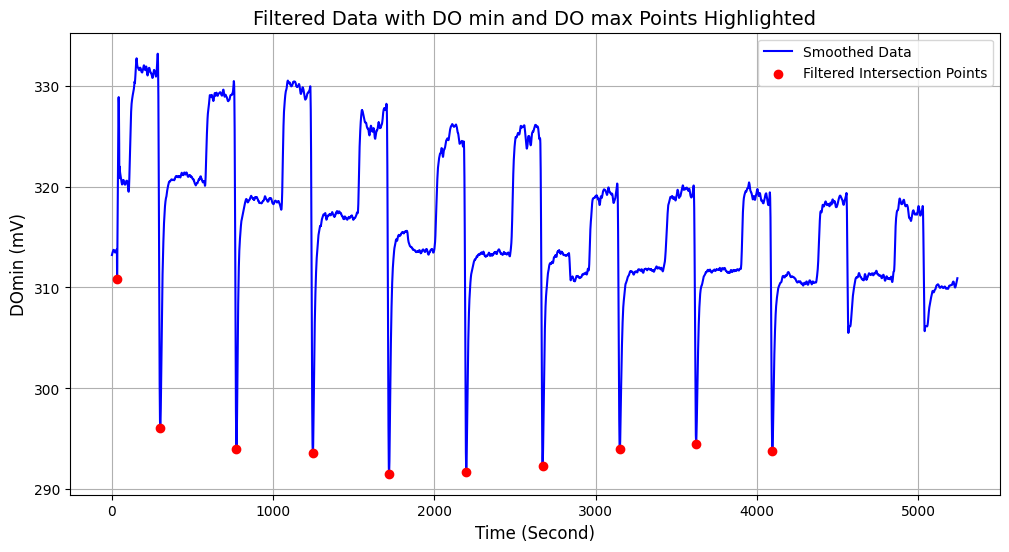

In [ ]:
from scipy.signal import savgol_filter
import matplotlib.pyplot as plt

# Load the data
result_data = pd.read_csv('/content/result_data.csv')  # Update with your file path

# Extract time and values from Sheet2
time = result_data['Time']
values = result_data['DO']

# Smooth the data using a Savitzky-Golay filter
# smoothed_values = savgol_filter(values, window_length=51, polyorder=3)
# smoothed_series = pd.Series(smoothed_values, index=time)

smoothed_values = savgol_filter(values, window_length=15, polyorder=2)  # Giảm window_length và polyorder
smoothed_series = pd.Series(smoothed_values, index=time)

# Detect trends
gradient = np.gradient(smoothed_values)
trend_changes = np.where(np.diff(np.sign(gradient)) != 0)[0] + 1
trend_changes = np.insert(trend_changes, 0, 0)
trend_changes = np.append(trend_changes, len(time) - 1)

# Separate increasing and decreasing trends
increasing_trends = []
decreasing_trends = []

for i in range(len(trend_changes) - 1):
    start_idx = trend_changes[i]
    end_idx = trend_changes[i + 1]
    segment_time = time.iloc[start_idx:end_idx].values
    segment_values = smoothed_values[start_idx:end_idx]
    if gradient[start_idx] > 0:
        increasing_trends.append((segment_time, segment_values))
    else:
        decreasing_trends.append((segment_time, segment_values))

# Ensure all trends are valid before calculating magnitudes
valid_increasing_trends = [seg for seg in increasing_trends if len(seg[1]) > 0]
valid_decreasing_trends = [seg for seg in decreasing_trends if len(seg[1]) > 0]

# Calculate the average magnitude based on valid trends
average_magnitude = np.mean([
    abs(seg[1][-1] - seg[1][0]) for seg in valid_increasing_trends + valid_decreasing_trends
])

# Filter trends with magnitude larger than the average
magnitude_large_increasing_trends = [
    seg for seg in valid_increasing_trends if abs(seg[1][-1] - seg[1][0]) > average_magnitude
]
magnitude_large_decreasing_trends = [
    seg for seg in valid_decreasing_trends if abs(seg[1][-1] - seg[1][0]) > average_magnitude
]

# Find intersection points between large decreasing and increasing trends
intersection_points = []

for dec_seg in magnitude_large_decreasing_trends:
    dec_end_time = dec_seg[0][-1]
    for inc_seg in magnitude_large_increasing_trends:
        inc_start_time = inc_seg[0][0]
        if abs(dec_end_time - inc_start_time) <= 1:
            intersection_value = smoothed_series.loc[dec_end_time]
            intersection_points.append((dec_end_time, intersection_value))

# Create a DataFrame for intersection points
intersection_points_df = pd.DataFrame(intersection_points, columns=['Time (Second)', 'DOmin (mV)'])

# Filter points where value is more than double or less than half of adjacent points
filtered_intersection_points = []

for time_point, value in intersection_points:
    idx = time[time == time_point].index[0]  # Find index in the original data
    if 1 <= idx < len(smoothed_values) - 1:  # Ensure valid index range
        prev_value = smoothed_values[idx - 1]
        next_value = smoothed_values[idx + 1]
        local_max = max(prev_value, next_value)
        local_min = min(prev_value, next_value)
        # Check if value is more than double or less than half of adjacent values
        if not (value > 2 * local_max or value < 0.5 * local_min):
            filtered_intersection_points.append((time_point, value))

# Create a DataFrame for filtered intersection points
filtered_intersection_points_df = pd.DataFrame(
    filtered_intersection_points, columns=['Time (Second)', 'DOmin (mV)']
)

# Plot the full data with highlighted filtered intersection points
plt.figure(figsize=(12, 6))
plt.plot(time, smoothed_values, label='Smoothed Data', color='blue')
if not filtered_intersection_points_df.empty:
    plt.scatter(filtered_intersection_points_df['Time (Second)'], filtered_intersection_points_df['DOmin (mV)'],
                color='red', label='Filtered Intersection Points', zorder=5)
plt.title('Filtered Data with DO min and DO max Points Highlighted', fontsize=14)
plt.xlabel('Time (Second)', fontsize=12)
plt.ylabel('DOmin (mV)', fontsize=12)
plt.legend(['Smoothed Data', 'Filtered Intersection Points'])
plt.grid(True)
plt.show()


In [ ]:
intersection_points_df

,Time (Second),DOmin (mV)
0,33.0,310.863168
1,300.0,296.056655
2,773.0,293.952400
3,1246.0,293.592033
4,1719.0,291.548419
5,2198.0,291.739819
6,2672.0,292.273122
7,3150.0,293.956748
8,3624.0,294.492032
9,4096.0,293.752398


## Encoder-Decoder LSTM

### Train

In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from keras.optimizers import AdamW
from tensorflow.keras.layers import LSTM, RepeatVector, TimeDistributed, Dropout, Dense, Flatten
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, Callback
from tensorflow.keras.regularizers import l2
from sklearn.metrics import mean_squared_error
import numpy as np
import tensorflow as tf

# Đặt seed để đảm bảo tính ngẫu nhiên
seed = 42
np.random.seed(seed)
tf.random.set_seed(seed)

# Load data
data = pd.read_csv('/content/metadata-gga-txt.csv')

# List all sample names
sample_names = data['Sample_name'].unique()

# Initialize empty lists to store evaluation results
all_val_losses = []
all_test_losses = []
all_train_rmse = []
all_test_rmse = []
lookback = 7

# Define model with reduced number of neurons
model = Sequential([
    # Encoder
    LSTM(128, activation='relu', input_shape=(1, lookback)),
    RepeatVector(lookback), # This repeats the context vector for the decoder

    # Decoder
    LSTM(128, activation='relu', return_sequences=True),
    LSTM(64, activation='relu'), # Additional LSTM layer to process sequences
    Dense(1) # Final output layer to match the shape of y_true
    # TimeDistributed(Dense(1)), # Applies Dense layer to each time step of the output sequence
])

# Compile model with different learning rate
model.compile(optimizer='adam', loss='mse')
# model.compile(optimizer=AdamW(learning_rate=0.001), loss='huber')

# Theo dõi loss
sample_loss_history = {}

class LossHistory(Callback):
    def __init__(self, sample_name):
        super().__init__()
        self.sample_name = sample_name
        self.loss_history = []

    def on_epoch_end(self, epoch, logs=None):
        self.loss_history.append(logs.get("loss"))

callbacks = [
    EarlyStopping(monitor="val_loss", patience=10, verbose=1, mode="min"),
    ModelCheckpoint(filepath="best_model_h5.keras", monitor="val_loss", mode="min", save_best_only=True, save_weights_only=False, verbose=0)
]
count = 0
print("len(sample_name)", len(sample_names))

# Feed data into train
for sample_name in sample_names:
    print(f"Processing {sample_name}...")
    print(count)
    # Filter data for the current sample_name
    one_sample_data = data[data['Sample_name'] == sample_name].copy()
    one_sample_data.reset_index(drop=True, inplace=True)
    one_sample_data.drop(['Sample_name'], axis=1, inplace=True)
    one_sample_data.drop("Time", axis=1, inplace=True)
    one_sample_data = one_sample_data.values
    one_sample_data = one_sample_data.astype("float32")

    # Split data into train and test sets
    def split_data(dataframe, train_size, val_size):
        train_end = int(len(dataframe) * train_size)
        val_end = int(len(dataframe) * (train_size + val_size))
        train = dataframe[:train_end]
        val = dataframe[train_end:val_end]
        test = dataframe[val_end:]
        return train, val, test

    train, val, test = split_data(one_sample_data, 0.60, 0.20)

    # Scale data
    scaler_train = MinMaxScaler(feature_range=(0, 1))
    train = scaler_train.fit_transform(train)
    scaler_val = MinMaxScaler(feature_range=(0, 1))
    val = scaler_val.fit_transform(val)
    scaler_test = MinMaxScaler(feature_range=(0, 1))
    test = scaler_test.fit_transform(test)

    # Create features
    def create_features(data, lookback):
        X, Y = [], []
        for i in range(lookback, len(data)):
            X.append(data[i - lookback:i, 0])
            Y.append(data[i, 0])
        return np.array(X), np.array(Y)

    X_train, y_train = create_features(train, lookback)
    X_val, y_val = create_features(val, lookback)
    X_test, y_test = create_features(test, lookback)

    X_train = np.reshape(X_train, (X_train.shape[0], 1, X_train.shape[1]))
    X_val = np.reshape(X_val, (X_val.shape[0], 1, X_val.shape[1]))
    X_test = np.reshape(X_test, (X_test.shape[0], 1, X_test.shape[1]))

    y_train = y_train.reshape(-1, 1)
    y_val = y_val.reshape(-1, 1)
    y_test = y_test.reshape(-1, 1)

    # Tạo LossHistory callback cho mỗi sample_name
    loss_history_callback = LossHistory(sample_name)
    callbacks_with_history = callbacks + [loss_history_callback]

    # Train model with different batch size
    model.fit(x=X_train,
              y=y_train,
              epochs=100,
              batch_size=32,
              validation_data=(X_val, y_val),
              callbacks=callbacks,
              shuffle=False,
              verbose=0)


    # Lưu loss history
    sample_loss_history[sample_name] = loss_history_callback.loss_history

    # Evaluate model
    val_loss = model.evaluate(X_val, y_val, batch_size=32, verbose=0)
    # print(f"\nValidation loss: {100.0 * val_loss:.1f}%")

    test_loss = model.evaluate(X_test, y_test, batch_size=32, verbose=0)
    # print(f"\nTest loss: {100.0 * test_loss:.1f}%")

    train_predict = model.predict(X_train, verbose=0)
    val_predict = model.predict(X_val, verbose=0)
    test_predict = model.predict(X_test, verbose=0)

    train_predict = scaler_train.inverse_transform(train_predict)
    val_predict = scaler_val.inverse_transform(val_predict)
    test_predict = scaler_test.inverse_transform(test_predict)

    y_train = scaler_train.inverse_transform(y_train)
    y_val = scaler_val.inverse_transform(y_val)
    y_test = scaler_train.inverse_transform(y_test)

    train_rmse = np.sqrt(mean_squared_error(y_train, train_predict))
    val_rmse = np.sqrt(mean_squared_error(y_val, val_predict))
    test_rmse = np.sqrt(mean_squared_error(y_test, test_predict))

    # print(f"Train RMSE: {train_rmse:.4f}")
    # print(f"Validation RMSE: {val_rmse:.4f}")
    # print(f"Test RMSE: {test_rmse:.4f}")

    # Append results to lists
    all_val_losses.append(val_loss)
    all_test_losses.append(test_loss)
    all_train_rmse.append(train_rmse)
    all_test_rmse.append(test_rmse)
    count +=1
# Save the model after training
model.save("enc-dec_lstm_model.h5")

# Print overall evaluation results
print("\nOverall evaluation results:")
print(f"Average val loss: {np.mean(all_val_losses) * 100:.1f}%")
print(f"Average test loss: {np.mean(all_test_losses) * 100:.1f}%")
print(f"Average train RMSE: {np.mean(all_train_rmse):.4f}")
print(f"Average test RMSE: {np.mean(all_test_rmse):.4f}")

len(sample_name) 157
Processing N4-10-5-01042024-Q=49.81mL_phút-3.txt...
0
Epoch 15: early stopping
Processing N4-10-5-27032024-Q=50.45mL_phút-1.txt...
1
Epoch 20: early stopping
Processing N4-10-5-29032024-Q=50.81mL_phút-2.txt...
2
Epoch 10: early stopping
Processing N4-15-10-01042024-Q=49.88mL-phút-2.txt...
3
Epoch 10: early stopping
Processing N4-15-10-27032024-Q=49.66mL_phút-1.txt...
4
Epoch 25: early stopping
Processing N4-5-0-01042024-Q=49.99mL_phút-2.txt...
5
Epoch 10: early stopping
Processing N4-5-0-29032024-Q=50.19mL_phút-1.txt...
6
Epoch 10: early stopping
Processing U1-10-5-02042024-Q=49.74mL_phút-4.txt...
7
Epoch 15: early stopping
Processing U1-10-5-03042024-Q=50.41mL_phút-5.txt...
8
Epoch 10: early stopping
Processing U1-12.5-7.5-04042024-Q=49.9mL_phút-1.txt...
9
Epoch 10: early stopping
Processing U1-12.5-7.5-08042024-Q=50mL_phút-2.txt...
10
Epoch 10: early stopping
Processing U1-15-10-02042024-Q=49.81mL-phút-3.txt...
11
Epoch 33: early stopping
Processing U1-15-10-0304


Overall evaluation results:
Average val loss: 0.1%
Average test loss: 0.1%
Average train RMSE: 0.2322
Average test RMSE: 2.3193



Validation loss: 0.0%

Test loss: 0.0%
Train RMSE: 1.4268
Validation RMSE: 0.2615
Test RMSE: 26.3712


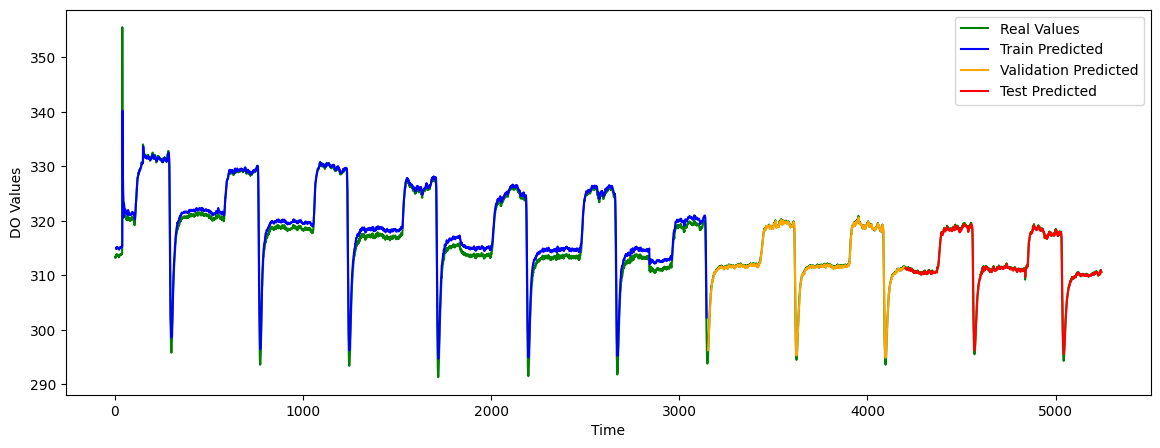

In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import load_model
from sklearn.metrics import mean_squared_error
import numpy as np
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.optimizers import AdamW
from keras.layers import LSTM, Dropout, Dense
from keras.regularizers import l2

# # Load the trained model
# model = load_model('/content/final_model.h5')

lookback = 7

# Recreate the model architecture
# Define model with reduced number of neurons
model = Sequential([
    # Encoder
    LSTM(128, activation='relu', input_shape=(1, lookback)),
    RepeatVector(lookback), # This repeats the context vector for the decoder

    # Decoder
    LSTM(128, activation='relu', return_sequences=True),
    LSTM(64, activation='relu'), # Additional LSTM layer to process sequences
    Dense(1) # Final output layer to match the shape of y_true
    # TimeDistributed(Dense(1)), # Applies Dense layer to each time step of the output sequence
])

# Load the model weights
# model.load_weights('/content/final_new_model.weights.h5')
model.load_weights('/content/enc-dec_lstm_model.h5')

# model.compile(optimizer=AdamW(learning_rate=0.001), loss='huber') # optimizer = adam hoặc adamW
model.compile(optimizer='adam', loss='mse')

# Now you can use the model to make predictions
# For example:
# predictions = model.predict(your_input_data)


# Load data
data = pd.read_csv('/content/metadata-gga-txt.csv')
sample_name = 'U100-H3-VS2-7.5-2.5-03072024-Q=50.66mL-phút-5.txt'

# Filter data for the specified sample_name
one_sample_data = data[data['Sample_name'] == sample_name].copy()
one_sample_data.reset_index(drop=True, inplace=True)
one_sample_data.drop(['Sample_name'], axis=1, inplace=True)
one_sample_data.drop("Time", axis=1, inplace=True)
one_sample_data = one_sample_data.values
one_sample_data = one_sample_data.astype("float32")

# Split data into train and test sets
def split_data(dataframe, train_size, val_size):
    train_end = int(len(dataframe) * train_size)
    val_end = int(len(dataframe) * (train_size + val_size))
    train = dataframe[:train_end]
    val = dataframe[train_end:val_end]
    test = dataframe[val_end:]
    return train, val, test

train, val, test = split_data(one_sample_data, 0.60, 0.20)

# Scale data
scaler_train = MinMaxScaler(feature_range=(0, 1))
train = scaler_train.fit_transform(train)
scaler_val = MinMaxScaler(feature_range=(0, 1))
val = scaler_val.fit_transform(val)
scaler_test = MinMaxScaler(feature_range=(0, 1))
test = scaler_test.fit_transform(test)

# Create features
def create_features(data, lookback):
    X, Y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i - lookback:i, 0])
        Y.append(data[i, 0])
    return np.array(X), np.array(Y)

X_train, y_train = create_features(train, lookback)
X_val, y_val = create_features(val, lookback)
X_test, y_test = create_features(test, lookback)

X_train = np.reshape(X_train, (X_train.shape[0], 1, X_train.shape[1]))
X_val = np.reshape(X_val, (X_val.shape[0], 1, X_val.shape[1]))
X_test = np.reshape(X_test, (X_test.shape[0], 1, X_test.shape[1]))

y_train = y_train.reshape(-1, 1)
y_val = y_val.reshape(-1, 1)
y_test = y_test.reshape(-1, 1)

# Evaluate model
val_loss = model.evaluate(X_val, y_val, batch_size=32, verbose=0)
print(f"\nValidation loss: {100.0 * val_loss:.1f}%")

test_loss = model.evaluate(X_test, y_test, batch_size=32, verbose=0)
print(f"\nTest loss: {100.0 * test_loss:.1f}%")

train_predict = model.predict(X_train, verbose=0)
val_predict = model.predict(X_val, verbose=0)
test_predict = model.predict(X_test, verbose=0)

train_predict = scaler_train.inverse_transform(train_predict)
val_predict = scaler_val.inverse_transform(val_predict)
test_predict = scaler_test.inverse_transform(test_predict)

y_train = scaler_train.inverse_transform(y_train)
y_val = scaler_val.inverse_transform(y_val)
y_test = scaler_train.inverse_transform(y_test)

train_rmse = np.sqrt(mean_squared_error(y_train, train_predict))
val_rmse = np.sqrt(mean_squared_error(y_val, val_predict))
test_rmse = np.sqrt(mean_squared_error(y_test, test_predict))

print(f"Train RMSE: {train_rmse:.4f}")
print(f"Validation RMSE: {val_rmse:.4f}")
print(f"Test RMSE: {test_rmse:.4f}")

# Prepare data for visualization
result_data = data[data['Sample_name'] == sample_name].copy()
result_data.reset_index(drop=True, inplace=True) # Reset index for result_data
train_prediction_data = result_data[lookback:len(train)]
val_prediction_data = result_data[len(train)+lookback:len(train)+len(val)]
test_prediction_data = result_data[len(train)+len(val)+lookback:]

train_prediction_data["Predicted"] = train_predict
val_prediction_data["Predicted"] = val_predict
test_prediction_data["Predicted"] = test_predict

# Plotting
plt.figure(figsize=(14, 5))
plt.plot(result_data.index, result_data["DO"], color = "green", label="Real Values")
plt.plot(train_prediction_data.index, train_prediction_data["Predicted"], color="blue", label="Train Predicted")
plt.plot(val_prediction_data.index, val_prediction_data["Predicted"], color="orange", label="Validation Predicted")
plt.plot(test_prediction_data.index, test_prediction_data["Predicted"], color="red", label="Test Predicted")
plt.xlabel("Time")
plt.ylabel("DO Values")
plt.legend()
plt.show()


# Testing model

## 3- Preparing the Data

In [ ]:
all_data = data.copy()
all_data.head()

,Time,DO,Sample_name
0,1.0,282.720001,N4-10-5-01042024-Q=49.81mL_phút-3.txt
1,2.0,282.720001,N4-10-5-01042024-Q=49.81mL_phút-3.txt
2,3.0,282.779999,N4-10-5-01042024-Q=49.81mL_phút-3.txt
3,4.0,282.739990,N4-10-5-01042024-Q=49.81mL_phút-3.txt
4,5.0,282.739990,N4-10-5-01042024-Q=49.81mL_phút-3.txt


In [ ]:
sample_name = 'U100-H3-VS2-7.5-2.5-03072024-Q=50.66mL-phút-5.txt'
one_sample_data = all_data[all_data['Sample_name']== 'U100-H3-VS2-7.5-2.5-03072024-Q=50.66mL-phút-5.txt']
one_sample_data.reset_index(drop=True, inplace=True)
one_sample_data.drop(['Sample_name'], axis = 1, inplace = True)
one_sample_data

,Time,DO
0,1.0,313.300013
1,2.0,313.300013
2,3.0,313.300013
3,4.0,313.199997
4,5.0,313.600004
...,...,...
5239,5240.0,310.900003
5240,5241.0,310.999990
5241,5242.0,310.699999
5242,5243.0,310.699999


In [ ]:
one_sample_data.drop("Time",axis=1,inplace=True)
one_sample_data

,DO
0,313.300013
1,313.300013
2,313.300013
3,313.199997
4,313.600004
...,...
5239,310.900003
5240,310.999990
5241,310.699999
5242,310.699999


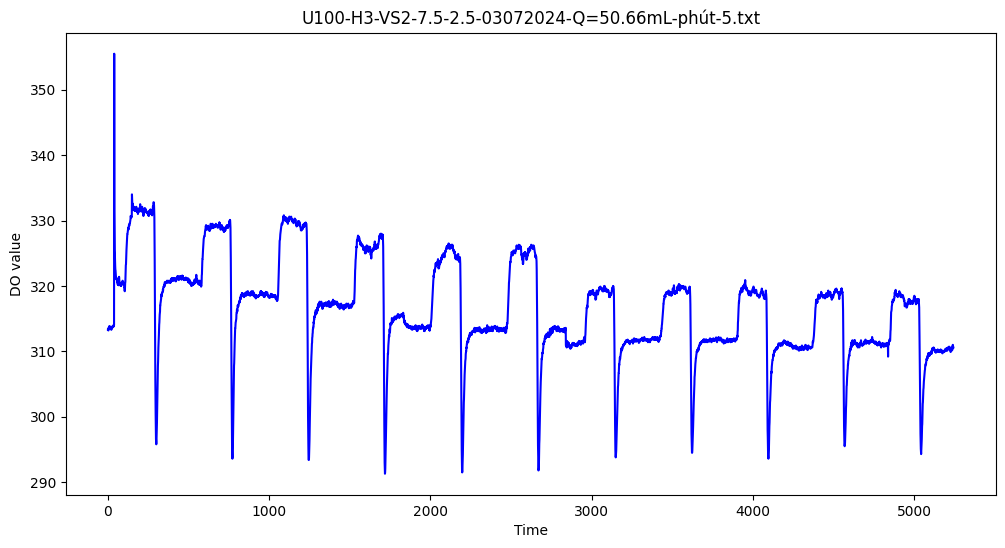

In [ ]:
result_data=one_sample_data.copy()
plt.figure(figsize=(12,6))
plt.plot(one_sample_data["DO"],color="blue");
plt.ylabel("DO value")
plt.title(sample_name)
plt.xlabel("Time")
plt.show()

#### convert to numpy array

In [ ]:
one_sample_data=one_sample_data.values
one_sample_data[0:5]

array([[313.3000135],
       [313.3000135],
       [313.3000135],
       [313.1999969],
       [313.6000037]])

#### It is necessary to define float 32 for neural network

In [ ]:
one_sample_data=one_sample_data.astype("float32")

#### Let's make the Train-Test distinction as a function

In [ ]:
def split_data(dataframe,test_size):
    pos=int(round(len(dataframe)*(1-test_size)))
    train=dataframe[:pos]
    test=dataframe[pos:]
    return train,test,pos

train,test,pos=split_data(one_sample_data,0.20)
print(train.shape,test.shape)

(4195, 1) (1049, 1)


In [ ]:
scaler_train=MinMaxScaler(feature_range=(0,1))
train=scaler_train.fit_transform(train)
scaler_test=MinMaxScaler(feature_range=(0,1))
test=scaler_test.fit_transform(test)
train[0:5]

array([[0.3426795 ],
       [0.3426795 ],
       [0.3426795 ],
       [0.3411212 ],
       [0.34735203]], dtype=float32)

In [ ]:
test[0:5]

array([[0.67984295],
       [0.67984295],
       [0.6719389 ],
       [0.67984295],
       [0.67984295]], dtype=float32)

In [ ]:
def create_features(data,lookback):
    X,Y=[],[]
    for i in range(lookback,len(data)):
        X.append(data[i-lookback:i,0])
        Y.append(data[i,0])
    return np.array(X),np.array(Y)
lookback=32

#### Training Dataset

In [ ]:
X_train,y_train=create_features(train,lookback)

#### Testing Dataset

In [ ]:
X_test,y_test=create_features(test,lookback)

In [ ]:
print(X_train.shape,y_train.shape,X_test.shape,y_test.shape)

(4163, 32) (4163,) (1017, 32) (1017,)


In [ ]:
X_train[0:5]

array([[0.3426795 , 0.3426795 , 0.3426795 , 0.3411212 , 0.34735203,
        0.3457942 , 0.3457942 , 0.35046768, 0.3457942 , 0.35046768,
        0.35046768, 0.34735203, 0.34890938, 0.34890938, 0.35046768,
        0.34735203, 0.34735203, 0.3457942 , 0.3457942 , 0.3457942 ,
        0.3457942 , 0.3426795 , 0.3457942 , 0.3457942 , 0.34735203,
        0.34890938, 0.35046768, 0.34890938, 0.34890938, 0.35046768,
        0.34890938, 0.35046768],
       [0.3426795 , 0.3426795 , 0.3411212 , 0.34735203, 0.3457942 ,
        0.3457942 , 0.35046768, 0.3457942 , 0.35046768, 0.35046768,
        0.34735203, 0.34890938, 0.34890938, 0.35046768, 0.34735203,
        0.34735203, 0.3457942 , 0.3457942 , 0.3457942 , 0.3457942 ,
        0.3426795 , 0.3457942 , 0.3457942 , 0.34735203, 0.34890938,
        0.35046768, 0.34890938, 0.34890938, 0.35046768, 0.34890938,
        0.35046768, 0.34890938],
       [0.3426795 , 0.3411212 , 0.34735203, 0.3457942 , 0.3457942 ,
        0.35046768, 0.3457942 , 0.35046768, 0.3504

#### There are 20 features in total here, so we added the day 20 days before the relevant date to the data set.

In [ ]:
y_test[0:5]

array([0.66007996, 0.6719389 , 0.6719389 , 0.652174  , 0.66403294],
      dtype=float32)

#### stock closing prices

In [ ]:
X_train=np.reshape(X_train,(X_train.shape[0],1,X_train.shape[1]))
X_test=np.reshape(X_test,(X_test.shape[0],1,X_test.shape[1]))
y_train=y_train.reshape(-1,1)
y_test=y_test.reshape(-1,1)
print(X_train.shape,y_train.shape,X_test.shape,y_test.shape)

(4163, 1, 32) (4163, 1) (1017, 1, 32) (1017, 1)


## 4- Modeling

Dựa trên kết quả huấn luyện, bạn đã gặp vấn đề với **early stopping** do `val_loss` không cải thiện sau 3 epoch liên tiếp. Điều này có thể xảy ra khi mô hình của bạn bị **overfitting**, **underfitting**, hoặc cấu trúc mô hình và tham số tối ưu chưa phù hợp. Để cải thiện, bạn có thể thực hiện các điều chỉnh sau:

---

### 1. **Điều chỉnh cấu trúc mô hình**:
- **Tăng số lượng đơn vị LSTM**:
  ```python
  model.add(LSTM(units=100, activation="relu", return_sequences=True, input_shape=(X_train.shape[1], lookback)))
  model.add(LSTM(units=50, activation="relu"))
  ```
  Thêm một lớp LSTM với `return_sequences=True` để giữ thông tin qua các bước thời gian.

- **Tăng số tầng Dense**:
  ```python
  model.add(Dense(units=10, activation="relu"))
  model.add(Dense(units=1))
  ```

- **Thử các hàm kích hoạt khác**:
  - `tanh` hoặc `sigmoid` có thể hoạt động tốt với dữ liệu chuỗi thời gian.

---

### 2. **Điều chỉnh tham số tối ưu hóa**:
- **Học suất (learning rate)**:
  Sử dụng `Adam` với learning rate thấp hơn:
  ```python
  from tensorflow.keras.optimizers import Adam
  model.compile(loss="mean_squared_error", optimizer=Adam(learning_rate=0.001))
  ```

- **Thay đổi hàm mất mát**:
  Nếu dữ liệu có outliers, sử dụng hàm `Huber`:
  ```python
  model.compile(loss="huber", optimizer="adam")
  ```

---

### 3. **Cải thiện kỹ thuật huấn luyện**:
- **Tăng patience cho EarlyStopping**:
  ```python
  callbacks = [EarlyStopping(monitor="val_loss", patience=10, verbose=1, mode="min")]
  ```

- **Thay đổi batch_size**:
  Thử nghiệm với các giá trị khác (16, 32, hoặc 64).

- **Shuffling dữ liệu**:
  Nếu dữ liệu không phụ thuộc hoàn toàn vào thứ tự thời gian:
  ```python
  history = model.fit(x=X_train, y=y_train, epochs=100, batch_size=32, validation_data=(X_test, y_test), callbacks=callbacks, shuffle=True)
  ```

---

### 4. **Tiền xử lý dữ liệu tốt hơn**:
- **Chuẩn hóa (Normalization)**:
  Chuẩn hóa tất cả các đặc trưng (features) về cùng khoảng giá trị:
  ```python
  from sklearn.preprocessing import MinMaxScaler
  scaler = MinMaxScaler()
  X_train = scaler.fit_transform(X_train)
  X_test = scaler.transform(X_test)
  ```

- **Thử nghiệm các giá trị `lookback` khác**:
  Xem xét tăng/giảm số bước thời gian trong quá khứ:
  ```python
  lookback = 30  # Số ngày quá khứ
  ```

---

### 5. **Thử nghiệm các kiến trúc nâng cao**:
- **GRU (Gated Recurrent Units)**:
  GRU thường ít phức tạp hơn LSTM nhưng hiệu quả tương tự:
  ```python
  from tensorflow.keras.layers import GRU
  model.add(GRU(units=50, activation="relu", input_shape=(X_train.shape[1], lookback)))
  ```

- **Attention Mechanism**:
  Thêm cơ chế Attention để cải thiện khả năng học các mẫu phức tạp.

---

### 6. **Theo dõi hiệu suất**:
- Vẽ đồ thị loss và val_loss:
  ```python
  import matplotlib.pyplot as plt
  plt.plot(history.history['loss'], label='Training Loss')
  plt.plot(history.history['val_loss'], lƯabel='Validation Loss')
  plt.legend()
  plt.show()
  ```

Hãy thử từng bước cải thiện trên và quan sát sự thay đổi. Nếu cần thêm hỗ trợ, hãy chia sẻ thông tin về cấu trúc dữ liệu và hiệu suất mô hình hiện tại!

In [ ]:
model=Sequential()
#model.add(LSTM(units=50,
#              activation="relu",
#              input_shape=(X_train.shape[1],lookback)))
model.add(LSTM(units=100, activation="relu", return_sequences=True, input_shape=(X_train.shape[1], lookback)))
model.add(LSTM(units=50, activation="relu"))
model.add(Dropout(0.2))
model.add(Dense(1))
#model.add(Dense(units=10, activation="relu"))
#model.add(Dense(units=1))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 1, 100)              │          53,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 50)                  │          30,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 50)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 83,451 (325.98 KB)

 Trainable params: 83,451 (325.98 KB)

 Non-trainable params: 0 (0.00 B)

#### Setting optimization and evaluation metrics

In [ ]:
from tensorflow.keras.optimizers import Adam
#model.compile(loss="mean_squared_error",optimizer="adam")
#model.compile(loss="mean_squared_error", optimizer=Adam(learning_rate=0.001))
model.compile(loss="huber", optimizer="adam")
callbacks=[EarlyStopping(monitor="val_loss",patience=10,verbose=1,mode="min"),
          ModelCheckpoint(filepath="mymodel.h5.keras",monitor="val_loss",mode="min",
                         save_best_only=True,save_weights_only=False,verbose=1)]

history = model.fit(x=X_train,
                    y=y_train,
                    epochs=100,
                    batch_size=64,
                    validation_data=(X_test,y_test),
                    callbacks=callbacks,
                    shuffle=False)

Epoch 1/100
59/66 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0786
Epoch 1: val_loss improved from inf to 0.03197, saving model to mymodel.h5.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0735 - val_loss: 0.0320
Epoch 2/100
62/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0057
Epoch 2: val_loss improved from 0.03197 to 0.02309, saving model to mymodel.h5.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0056 - val_loss: 0.0231
Epoch 3/100
65/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0046
Epoch 3: val_loss improved from 0.02309 to 0.00677, saving model to mymodel.h5.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0046 - val_loss: 0.0068
Epoch 4/100
58/66 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0038
Epoch 4: val_loss improved from 0.00677 to 0.00312, saving model to mymodel.h5.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0037 - val_loss: 0.0031
Epoch 5/100
63/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0026
Epoch 5: val_loss improved from 0.00312 t

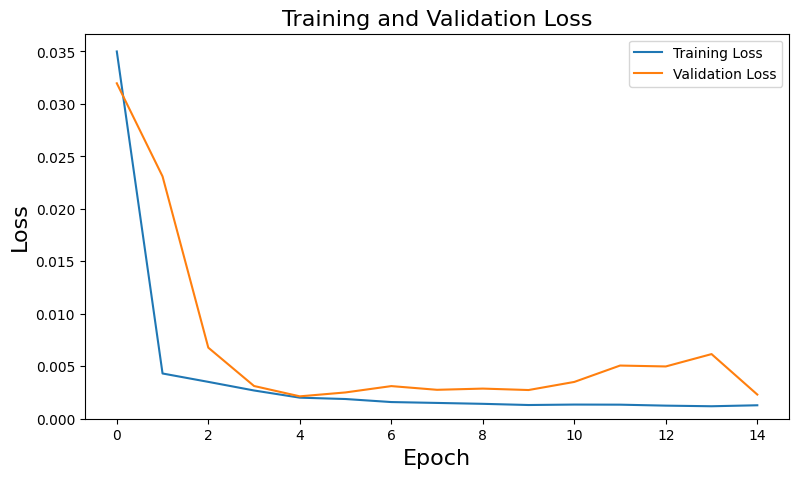

In [ ]:
plt.figure(figsize=(20,5))
plt.subplot(1,2,2)
plt.plot(history.history["loss"],label="Training Loss")
plt.plot(history.history["val_loss"],label="Validation Loss")
plt.legend(loc="upper right")
plt.xlabel("Epoch",fontsize=16)
plt.ylabel("Loss",fontsize=16)
plt.ylim([0,max(plt.ylim())])
plt.title("Training and Validation Loss",fontsize=16)
plt.show()

#### (The expression loss is the mean squared error value, that is, the mean squared expression of the actual values and the estimated values.)

## 5-Evaluation

In [ ]:
loss=model.evaluate(X_test,y_test,batch_size=20)

51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0022


In [ ]:
print("\nTest loss:%.1f%%"%(100.0*loss))


Test loss:0.2%


In [ ]:
train_predict=model.predict(X_train)
test_predict=model.predict(X_test)
train_predict=scaler_train.inverse_transform(train_predict)
test_predict=scaler_test.inverse_transform(test_predict)
y_train=scaler_train.inverse_transform(y_train)
y_test=scaler_test.inverse_transform(y_test)

131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


#### RMSE value to train dataset

In [ ]:
train_rmse=np.sqrt(mean_squared_error(y_train,train_predict))
test_rmse=np.sqrt(mean_squared_error(y_test,test_predict,))
print(f"Train RMSE:{train_rmse}")
print(f"Test RMSE:{test_rmse}")

Train RMSE:2.076944351196289
Test RMSE:1.7173770666122437


#### The mistake that vninedex will be made in the next period is??

In [ ]:
train_prediction_data=result_data[lookback:pos]
train_prediction_data["Predicted"]=train_predict
train_prediction_data.tail()

,DO,Predicted
4190,311.600000,311.199341
4191,311.300009,311.263977
4192,311.600000,311.268890
4193,311.699987,311.296875
4194,311.500013,311.379150


In [ ]:
test_prediction_data=result_data[pos+lookback:]
test_prediction_data["Predicted"]=test_predict
test_prediction_data.tail()

,DO,Predicted
5239,310.900003,309.581635
5240,310.999990,309.740997
5241,310.699999,309.911224
5242,310.699999,309.951324
5243,310.600012,309.971619


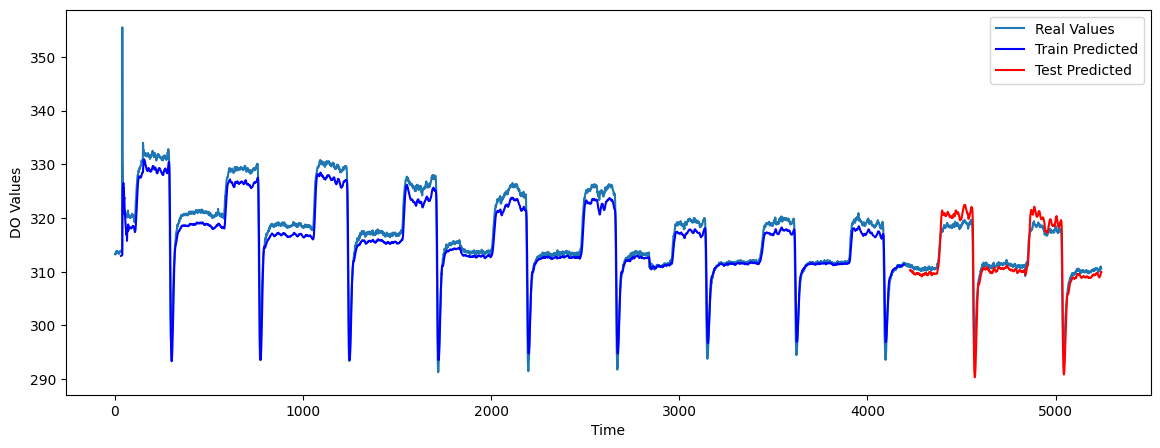

In [ ]:
plt.figure(figsize=(14,5))
plt.plot(result_data,label="Real Values")
plt.plot(train_prediction_data["Predicted"],color="blue",label="Train Predicted")
plt.plot(test_prediction_data["Predicted"],color="red",label="Test Predicted")
plt.xlabel("Time")
plt.ylabel("DO Values")
plt.legend()
plt.show()